# 04 — Baseline Validation

**Goal:** Validate that composite novelty scores correctly separate NOVEL papers from SKG papers.

This replaces the abandoned supervised classifier — dropped due to temporal leakage (SciND labels perfectly correlate with publication year, making classification trivial and meaningless).

**Pass condition:** NOVEL papers should score significantly higher than SKG on composite novelty.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

FEATURE_MATRIX = "../../outputs/final/novelty_feature_matrix_with_score.csv"
PAPER_NODES    = "../../outputs/final/paper_nodes.csv"
OUT_DIR        = "../../outputs/final/"

In [16]:
# Load and merge
fm = pd.read_csv('../../outputs/final/novelty_feature_matrix_with_score.csv')
pn = pd.read_csv("../../outputs/final/paper_nodes.csv")[['node_id', 'split', 'domain']]
pn = pn.rename(columns={'node_id': 'paper_id'})

df = fm.merge(pn, on='paper_id', how='left')
df = df[df['split'].isin(['NOVEL', 'SKG'])].copy()

print(f"Total papers in analysis: {len(df)}")
print(df['split'].value_counts())
print()
print("Composite novelty by split:")
print(df.groupby('split')['composite_novelty'].describe().round(4))

Total papers in analysis: 2511
split
SKG      2099
NOVEL     412
Name: count, dtype: int64

Composite novelty by split:
        count    mean     std     min     25%     50%     75%     max
split                                                                
NOVEL   412.0  0.7946  0.0505  0.2376  0.7647  0.7863  0.8290  0.9123
SKG    2099.0  0.7892  0.0466  0.1658  0.7697  0.7887  0.8065  0.9629


In [17]:
df

,paper_id,year,semantic_knn,structural_novelty,triple_count,cited_by_count,reference_count,citation_signal,struct_norm,semantic_norm,citation_norm,composite_novelty,split,domain
0,SKG_SUM_7,2010,1.000000,1.000000,336,20,26,3.044522,1.000000,1.000000,0.336536,0.933654,SKG,SUM
1,SKG_MT_1325,2010,1.000000,1.000000,107,34,21,3.555348,1.000000,1.000000,0.393002,0.939300,SKG,MT
2,SKG_MT_1231,2010,1.000000,1.000000,59,4,14,1.609438,1.000000,1.000000,0.177904,0.917790,SKG,MT
3,SKG_MT_1232,2010,1.000000,1.000000,95,14,13,2.708050,1.000000,1.000000,0.299343,0.929934,SKG,MT
4,SKG_MT_388,2010,1.000000,1.000000,61,32,29,3.496508,1.000000,1.000000,0.386498,0.938650,SKG,MT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2506,NOVEL_MT_244,2022,0.947272,0.692308,117,4,30,1.609438,0.692308,0.877240,0.177904,0.770320,NOVEL,MT
2507,NOVEL_MT_280,2022,0.977790,0.553571,56,10,35,2.397895,0.553571,0.948293,0.265059,0.801025,NOVEL,MT
2508,NOVEL_MT_60,2022,0.941635,0.613333,75,7,0,2.079442,0.613333,0.864117,0.229858,0.750534,NOVEL,MT
2509,NOVEL_MT_306,2024,0.946806,0.674157,89,8,28,2.197225,0.674157,0.876156,0.242877,0.772428,NOVEL,MT


In [18]:
# 1. Summary statistics per split 
summary = df.groupby('split')['composite_novelty'].agg(['mean','median','std','count'])
summary.columns = ['Mean', 'Median', 'Std', 'Count']
print("Composite Novelty Summary")
print(summary.round(4))
print()
gap = summary.loc['NOVEL','Mean'] - summary.loc['SKG','Mean']
print(f"Mean gap (NOVEL - SKG): {gap:+.4f}")

Composite Novelty Summary
         Mean  Median     Std  Count
split                               
NOVEL  0.7946  0.7863  0.0505    412
SKG    0.7892  0.7887  0.0466   2099

Mean gap (NOVEL - SKG): +0.0054


In [19]:
# ── 2. Mann-Whitney U Test (non-parametric, no normality assumption) ──────────
novel_scores = df[df['split'] == 'NOVEL']['composite_novelty'].dropna()
skg_scores   = df[df['split'] == 'SKG']['composite_novelty'].dropna()

u_stat, p_value = stats.mannwhitneyu(novel_scores, skg_scores, alternative='greater')

# Effect size: rank-biserial correlation
n1, n2      = len(novel_scores), len(skg_scores)
effect_size = 1 - (2 * u_stat) / (n1 * n2)

print("=== Mann-Whitney U Test ===")
print(f"H0: NOVEL composite <= SKG composite")
print(f"H1: NOVEL composite  > SKG composite  (one-sided)")
print(f"U-statistic     : {u_stat:.2f}")
print(f"p-value         : {p_value:.6f}")
print(f"Effect size (r) : {effect_size:.4f}")
print()

if p_value < 0.05:
    print("RESULT: ✅ PASS — NOVEL papers score significantly higher. System validated.")
else:
    print("RESULT: ❌ FAIL — No significant difference detected.")

=== Mann-Whitney U Test ===
H0: NOVEL composite <= SKG composite
H1: NOVEL composite  > SKG composite  (one-sided)
U-statistic     : 450234.00
p-value         : 0.092437
Effect size (r) : -0.0413

RESULT: ❌ FAIL — No significant difference detected.


C:\Users\hp\AppData\Local\Temp\ipykernel_21752\2079477571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='split', y='composite_novelty',


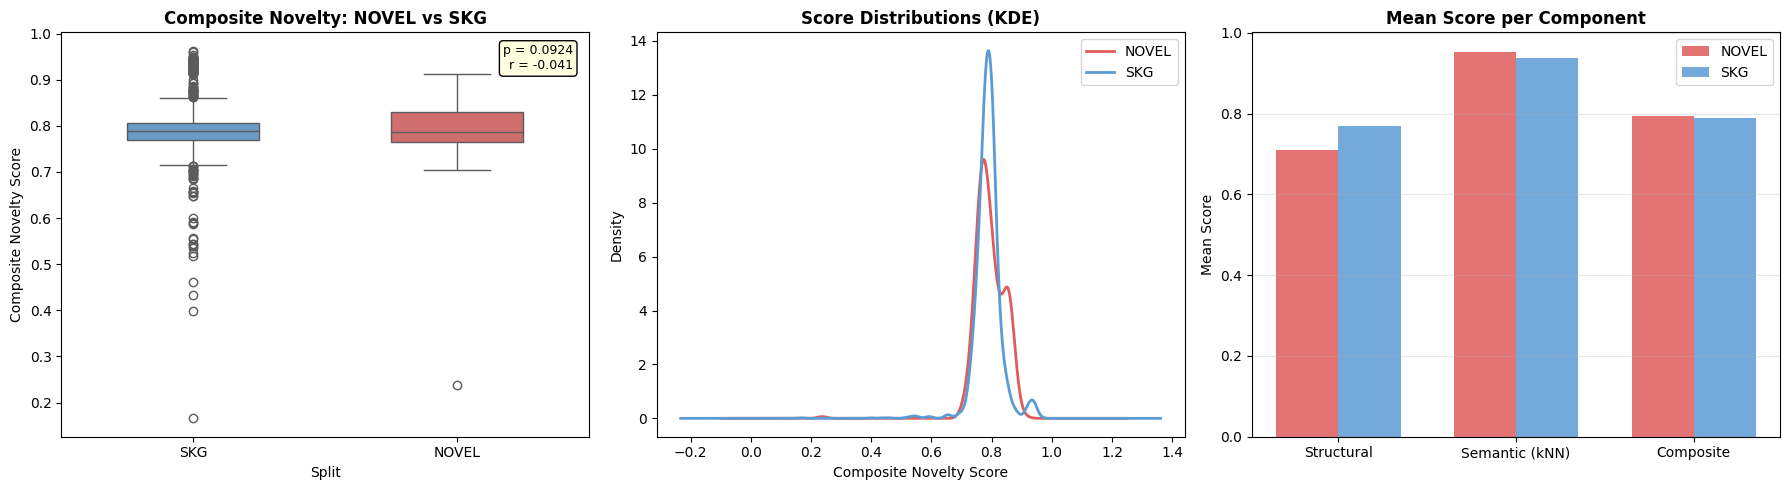

Saved: baseline_validation.png


In [20]:
# ── 3. Plots ──────────────────────────────────────────────────────────────────
palette = {'NOVEL': '#E05C5C', 'SKG': '#5B9BD5'}
order   = ['SKG', 'NOVEL']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Boxplot ---
sns.boxplot(data=df, x='split', y='composite_novelty',
            order=order, palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('Composite Novelty: NOVEL vs SKG', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Composite Novelty Score')
axes[0].annotate(f'p = {p_value:.4f}\nr = {effect_size:.3f}',
                 xy=(0.97, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# --- KDE ---
for split, color in palette.items():
    df[df['split'] == split]['composite_novelty'].dropna().plot.kde(
        ax=axes[1], label=split, color=color, linewidth=2)
axes[1].set_title('Score Distributions (KDE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Composite Novelty Score')
axes[1].legend()

# --- Per-component bar chart ---
components  = ['structural_novelty', 'semantic_knn', 'composite_novelty']
comp_labels = ['Structural', 'Semantic (kNN)', 'Composite']
means = df.groupby('split')[components].mean()

x = np.arange(len(comp_labels))
w = 0.35
axes[2].bar(x - w/2, means.loc['NOVEL'], w, label='NOVEL', color='#E05C5C', alpha=0.85)
axes[2].bar(x + w/2, means.loc['SKG'],   w, label='SKG',   color='#5B9BD5', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(comp_labels)
axes[2].set_ylabel('Mean Score')
axes[2].set_title('Mean Score per Component', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'baseline_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_validation.png")

In [22]:
# 4. Save results CSV 
results = pd.DataFrame([{
    'novel_mean'  : round(novel_scores.mean(), 4),
    'skg_mean'    : round(skg_scores.mean(), 4),
    'mean_gap'    : round(novel_scores.mean() - skg_scores.mean(), 4),
    'u_stat'      : round(u_stat, 2),
    'p_value'     : round(p_value, 6),
    'effect_size' : round(effect_size, 4),
    'significant' : p_value < 0.05
}])
results.to_csv(OUT_DIR + 'baseline_validation_results.csv', index=False)
print("Saved: baseline_validation_results.csv")
print(results.to_string(index=False))

Saved: baseline_validation_results.csv
 novel_mean  skg_mean  mean_gap   u_stat  p_value  effect_size  significant
     0.7946    0.7892    0.0054 450234.0 0.092437      -0.0413        False
